# Synthetic Data Generation for RAG Evaluation

Session 1 built a vector RAG application over a cat health guideline PDF. This
session creates an evaluation dataset for that application and uses the dataset
to compare two retrieval configurations. All generation, embedding, RAG, and
judge requests are routed through Vercel AI Gateway.

The workflow is:

~~~text
corpus -> knowledge graph -> synthetic examples -> human review
       -> LangSmith dataset -> baseline and candidate experiments
~~~

Synthetic examples reduce the cost of getting started, but generated references
are not automatically ground truth. We will inspect and curate them before using
them as evaluation targets.

> This is an educational cat health exercise, not veterinary advice. Generated
> questions and answers must not be used to diagnose, prescribe, or replace a
> veterinarian.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how Ragas builds a knowledge graph for test data generation.
- Distinguish single-hop specific, multi-hop specific, and multi-hop abstract queries.
- Generate and review synthetic questions, reference contexts, and reference answers.
- Route generation, embeddings, RAG, and judge calls through Vercel AI Gateway.
- Upload reviewed examples to a LangSmith dataset.
- Evaluate answer correctness, answer groundedness, and retrieval relevance.
- Run a controlled RAG experiment that changes one variable at a time.

## Table of Contents

- **Breakout Room #1: Synthetic Test Data with Ragas**
  - Task 1: Environment Setup
  - Task 2: Load the Cat Health Corpus
  - Task 3: Build and Enrich a Knowledge Graph
  - Task 4: Inspect the Query Distribution
  - Task 5: Generate and Inspect a Synthetic Test Set
  - Activity #1: Review and Curate the Dataset
- **Breakout Room #2: RAG Evaluation with LangSmith**
  - Task 6: Create a LangSmith Dataset
  - Task 7: Build a Baseline RAG Application
  - Task 8: Define RAG Evaluators
  - Task 9: Run the Baseline Experiment
  - Task 10: Change One Retrieval Variable and Re-Evaluate
  - Activity #2: Compare, Diagnose, and Iterate
  - Advanced Build: Add Robustness and Adversarial Cases

---
# Breakout Room #1
## Synthetic Test Data with Ragas

Ragas uses the source corpus to create a richer representation of its topics and
relationships. Query synthesizers then select scenarios from that representation
and generate questions plus reference answers.

The knowledge graph is a generation aid. It is not the graph used by the RAG
application in Breakout Room #2.

## Task 1: Environment Setup

From the <code>05_Synthetic_Data_Generation_for_RAG_Evals</code> folder:

~~~bash
uv sync
~~~

Then select the environment created by uv as this notebook's kernel.

Required accounts:

- Vercel AI Gateway for generation, embeddings, the RAG answer model, and judges
- LangSmith for the dataset and experiments

A direct OpenAI API key is not required. The OpenAI SDK is used only as a
protocol-compatible client pointed at Vercel AI Gateway.

The default synthetic test set is intentionally small. Ragas generation and
LLM-as-judge evaluation both make multiple model calls, so start small and scale
only after inspecting quality.

### Imports

In [1]:
from __future__ import annotations

import os
from collections import Counter
from getpass import getpass
from importlib.metadata import version
from pathlib import Path
from uuid import uuid4

import instructor
from IPython.display import display
from openai import OpenAI
from pydantic import BaseModel, field_validator

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langsmith import Client, evaluate
from openevals.llm import create_llm_as_judge
from openevals.prompts import (
    CORRECTNESS_PROMPT,
    RAG_GROUNDEDNESS_PROMPT,
    RAG_RETRIEVAL_RELEVANCE_PROMPT,
)

from ragas.embeddings import embedding_factory
from ragas.llms import llm_factory
from ragas.run_config import RunConfig
from ragas.testset import TestsetGenerator
from ragas.testset.graph import KnowledgeGraph, Node, NodeType
from ragas.testset.synthesizers import (
    MultiHopAbstractQuerySynthesizer,
    MultiHopSpecificQuerySynthesizer,
    SingleHopSpecificQuerySynthesizer,
    default_query_distribution,
)
from ragas.testset.transforms import (
    CustomNodeFilter,
    SummaryExtractor,
    apply_transforms,
    default_transforms_for_prechunked,
)

/home/fateme/Projects/aie_certificate/source/AIE10/05_Synthetic_Data_Generation_for_RAG_Evals/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### API Keys, Models, and Cost Controls

The notebook reads model names and budgets from environment variables so you can
tune cost without editing every cell. Vercel AI Gateway exposes an
OpenAI-compatible endpoint, so the OpenAI and LangChain clients only need a
different API key, base URL, and provider-qualified model ID.

See the [Vercel AI Gateway Python documentation](https://vercel.com/docs/ai-gateway/sdks-and-apis/python)
for the current authentication and endpoint details.

LangSmith uses <code>LANGSMITH_TRACING</code>. The older
<code>LANGCHAIN_TRACING_V2</code> name from the source notebook is no longer
needed here.

In [2]:
gateway_api_key = (
    os.environ.get("AI_GATEWAY_API_KEY")
    or os.environ.get("VERCEL_OIDC_TOKEN")
)

if not gateway_api_key:
    gateway_api_key = getpass("Vercel AI Gateway API Key: ")
    os.environ["AI_GATEWAY_API_KEY"] = gateway_api_key

if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass("LangSmith API Key: ")

os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault(
    "LANGSMITH_PROJECT",
    "aim-session-5-synthetic-rag-evals",
)

GATEWAY_BASE_URL = os.environ.get(
    "AI_GATEWAY_BASE_URL",
    "https://ai-gateway.vercel.sh/v1",
)
GENERATOR_MODEL_NAME = os.environ.get(
    "AIM_GENERATOR_MODEL",
    "openai/gpt-5.4-mini",
)
RAG_MODEL_NAME = os.environ.get(
    "AIM_RAG_MODEL",
    "openai/gpt-5.4-mini",
)
JUDGE_MODEL_NAME = os.environ.get(
    "AIM_JUDGE_MODEL",
    "openai/gpt-5.4-mini",
)
EMBEDDING_MODEL_NAME = os.environ.get(
    "AIM_EMBEDDING_MODEL",
    "openai/text-embedding-3-small",
)
TESTSET_SIZE = int(os.environ.get("AIM_TESTSET_SIZE", "6"))
MAX_CONCURRENCY = int(os.environ.get("AIM_MAX_CONCURRENCY", "2"))

gateway_models = {
    "generator": GENERATOR_MODEL_NAME,
    "rag": RAG_MODEL_NAME,
    "judge": JUDGE_MODEL_NAME,
    "embedding": EMBEDDING_MODEL_NAME,
}
for role, model_name in gateway_models.items():
    if "/" not in model_name:
        raise ValueError(
            f"{role} model must use a provider-qualified AI Gateway ID: "
            f"{model_name!r}"
        )

print(f"Ragas: {version('ragas')}")
print(f"LangSmith: {version('langsmith')}")
print(f"AI Gateway: {GATEWAY_BASE_URL}")
print(f"Generator model: {GENERATOR_MODEL_NAME}")
print(f"RAG model: {RAG_MODEL_NAME}")
print(f"Judge model: {JUDGE_MODEL_NAME}")
print(f"Embedding model: {EMBEDDING_MODEL_NAME}")
print(f"Synthetic examples: {TESTSET_SIZE}")
print(f"LangSmith tracing: {os.environ['LANGSMITH_TRACING']}")

Ragas: 0.4.4.dev8+g298b68274
LangSmith: 0.8.18
AI Gateway: https://ai-gateway.vercel.sh/v1
Generator model: openai/gpt-5.4-mini
RAG model: openai/gpt-5.4-mini
Judge model: openai/gpt-5.4-mini
Embedding model: openai/text-embedding-3-small
Synthetic examples: 6
LangSmith tracing: true


## Task 2: Load the Cat Health Corpus

The corpus is the bundled 2021 AAHA/AAFP Feline Life Stage Guidelines PDF used
in Session 1. <code>PyPDFLoader</code> extracts one LangChain document per page,
including page metadata that survives later chunking.

This gives the generator multiple related units to connect:

- hydration and urinary signs
- preventive care and senior care
- dental pain and behavior changes
- monitoring and emergency escalation

In [3]:
corpus_path = Path("data/cat_health_guidelines.pdf")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the course corpus at {corpus_path.resolve()}"
    )

pdf_loader = PyPDFLoader(str(corpus_path))
source_documents = pdf_loader.load()
source_documents = [
    document
    for document in source_documents
    if len(document.page_content.strip()) >= 200
]

for index, document in enumerate(source_documents):
    page_number = int(document.metadata.get("page", index)) + 1
    document.metadata.update(
        {
            "source": corpus_path.name,
            "document_type": "feline_life_stage_guidelines",
            "page_number": page_number,
        }
    )

print(f"Loaded {len(source_documents)} text-containing PDF pages")
for document in source_documents[:5]:
    page_number = document.metadata["page_number"]
    print(
        f"- page {page_number}: "
        f"{len(document.page_content)} characters"
    )

Loaded 20 text-containing PDF pages
- page 1: 4913 characters
- page 2: 2084 characters
- page 3: 5955 characters
- page 6: 5673 characters
- page 7: 3588 characters


Inspect one PDF page and its metadata. The metadata is useful for debugging,
trace inspection, and explaining where a retrieved chunk came from.

In [4]:
sample_document = source_documents[0]

print(sample_document.metadata)
print()
print(sample_document.page_content[:800])

{'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2021-02-02T08:52:15-05:00', 'author': '7123', 'moddate': '2021-02-02T07:53:51-07:00', 'title': 'djs_jaaha_56_5_COVER.indd', 'source': 'cat_health_guidelines.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1', 'document_type': 'feline_life_stage_guidelines', 'page_number': 1}

VETERINARY PRACTICE GUIDELINES
2021 AAHA/AAFP Feline Life Stage Guidelines*
Jessica Quimby, DVM, PhD, DACVIM y, Shannon Gowland, DVM, DABVP y, Hazel C. Carney, DVM, MS, DABVP,
Theresa DePorter, DVM, MRCVS, DACVB, DECAWBM, Paula Plummer, LVT, VTS (ECC, SAIM), Jodi Westropp,
DVM, PhD, DACVIM
ABSTRACT
The guidelines, authored by a Task Force ofexperts in feline clinical medicine, are an update and extension of the AAFP–AAHA
Feline Life Stage Guidelines published in 2010. The guidelines are published simultaneously in theJournal of Feline Medicine and
Surgery(volume 23, issue 3, pages 211–233, DOI: 10.1177

## Task 3: Build and Enrich a Knowledge Graph

The unrolled workflow makes the generation stages visible:

1. Treat each text-containing PDF page as a pre-chunked Ragas node.
2. Run Ragas extractors, embeddings, and relationship builders.
3. Save the graph so expensive enrichment can be reused.

Ragas remains responsible for graph enrichment and synthetic generation. The
newer pinned Ragas build exposes an official Instructor mode parameter, so its
LLM factory can use AI Gateway tool calls directly without custom wrappers.

In [5]:
gateway_client = OpenAI(
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)

generator_llm = llm_factory(
    GENERATOR_MODEL_NAME,
    provider="openai",
    client=gateway_client,
    mode=instructor.Mode.TOOLS,
    max_tokens=4096,
)
# Provider-qualified Gateway IDs bypass Ragas's GPT-5 parameter detection.
# Keep only the token limit supported by the Gateway route. max_retries is
# consumed locally by Instructor and is not sent to AI Gateway.
generator_llm.model_args = {
    "max_tokens": 4096,
    "max_retries": 3,
}

generator_embeddings = embedding_factory(
    "openai",
    model=EMBEDDING_MODEL_NAME,
    client=gateway_client,
)

ragas_run_config = RunConfig(
    timeout=180,
    max_retries=3,
    max_wait=30,
    max_workers=MAX_CONCURRENCY,
)

/tmp/ipykernel_44160/1199448542.py:21: DeprecationWarning: Importing embedding_factory from ragas.embeddings is deprecated. Import directly from ragas.embeddings.base or use modern providers: from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = embedding_factory(


Before building the graph, make one small structured-output request through
Ragas. This catches gateway authentication, model availability, and tool-calling
incompatibilities without waiting for every PDF page to retry.

In [6]:
class GatewayToolCallCheck(BaseModel):
    status: str


class NonEmptySummary(BaseModel):
    text: str

    @field_validator("text")
    @classmethod
    def require_text(cls, value):
        value = value.strip()
        if not value:
            raise ValueError("summary text cannot be empty")
        return value


gateway_check = generator_llm.generate(
    "Use the required tool with a short, non-empty status message.",
    GatewayToolCallCheck,
)
if not gateway_check.status.strip():
    raise RuntimeError("AI Gateway returned an empty tool-call check")

print(f"AI Gateway tool-based structured output: {gateway_check.status}")

AI Gateway tool-based structured output: ok


In [8]:
def build_prechunked_knowledge_graph(chunks):
    return KnowledgeGraph(
        nodes=[
            Node(
                type=NodeType.CHUNK,
                properties={
                    "page_content": chunk.page_content,
                    "document_metadata": dict(chunk.metadata),
                },
            )
            for chunk in chunks
            if chunk.page_content.strip()
        ]
    )


generation_chunks = list(source_documents)
knowledge_graph = build_prechunked_knowledge_graph(generation_chunks)

print(f"Ragas input chunks: {len(generation_chunks)}")
print(knowledge_graph)

Ragas input chunks: 20
KnowledgeGraph(nodes: 20, relationships: 0)


### Apply Ragas Transforms

Because the PDF loader already gives us coherent page-level chunks, use Ragas'
built-in pre-chunked transform pipeline. It skips headline extraction and
splitting, then applies Ragas summaries, embeddings, themes, named entities,
and relationship builders directly to the PDF pages. The parent-child node
filter is omitted because these page chunks intentionally have no parent nodes.
A non-empty output constraint makes Instructor retry blank Ragas summaries before
the built-in embedding transform runs.

In [10]:
knowledge_graph = build_prechunked_knowledge_graph(generation_chunks)
transforms = [
    transform
    for transform in default_transforms_for_prechunked(
        llm=generator_llm,
        embedding_model=generator_embeddings,
    )
    if not isinstance(transform, CustomNodeFilter)
]

summary_transform = next(
    transform
    for transform in transforms
    if isinstance(transform, SummaryExtractor)
)
summary_transform.prompt.output_model = NonEmptySummary

print("Ragas transform pipeline:")
for transform in transforms:
    nested = getattr(transform, "transformations", None)
    if nested is None:
        print(f"- {type(transform).__name__}")
    else:
        names = ", ".join(type(item).__name__ for item in nested)
        print(f"- Parallel({names})")

for transform in transforms:
    apply_transforms(
        knowledge_graph,
        transform,
        run_config=ragas_run_config,
    )
    if isinstance(transform, SummaryExtractor):
        empty_summary_nodes = [
            node
            for node in knowledge_graph.nodes
            if not str(node.get_property("summary") or "").strip()
        ]
        if empty_summary_nodes:
            raise RuntimeError(
                "Ragas did not produce non-empty summaries for "
                f"{len(empty_summary_nodes)} PDF chunks"
            )

print(knowledge_graph)

Ragas transform pipeline:
- SummaryExtractor
- Parallel(EmbeddingExtractor, ThemesExtractor, NERExtractor)
- Parallel(CosineSimilarityBuilder, OverlapScoreBuilder)


Applying SummaryExtractor: 100%|██████████| 20/20 [02:24<00:00,  7.23s/it]
Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/60 [00:00<?, ?it/s]/home/fateme/Projects/aie_certificate/source/AIE10/05_Synthetic_Data_Generation_for_RAG_Evals/.venv/lib/python3.12/site-packages/ragas/testset/transforms/base.py:198: UserWarning: Using sync embedding model OpenAIEmbeddings in async context. This may impact performance. Consider using an async-compatible embedding model for better performance.
  property_name, property_value = await self.extract(node)
Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]: 100%|██████████| 60/60 [04:58<00:00,  4.98s/it]
Applying [CosineSimilarityBuilder, OverlapScoreBuilder]: 100%|██████████| 2/2 [00:00<00:00, 23.52it/s]

KnowledgeGraph(nodes: 20, relationships: 45)


Inspect the graph at a high level. Different Ragas versions may add different
properties, so the notebook avoids depending on one exact internal schema.

In [11]:
node_type_counts = Counter(str(node.type) for node in knowledge_graph.nodes)

print("Node types:")
for node_type, count in node_type_counts.items():
    print(f"- {node_type}: {count}")

print(f"Relationships: {len(knowledge_graph.relationships)}")

for index, node in enumerate(knowledge_graph.nodes[:3], start=1):
    property_names = sorted(node.properties.keys())
    print(f"Node {index} properties: {property_names}")

Node types:
- NodeType.CHUNK: 20
Relationships: 45
Node 1 properties: ['document_metadata', 'entities', 'page_content', 'summary', 'summary_embedding', 'themes']
Node 2 properties: ['document_metadata', 'entities', 'page_content', 'summary', 'summary_embedding', 'themes']
Node 3 properties: ['document_metadata', 'entities', 'page_content', 'summary', 'summary_embedding', 'themes']


### Save and Reload the Graph

Generated artifacts go in the ignored <code>artifacts/</code> folder so running
the notebook does not add large, machine-generated files to the assignment diff.

In [12]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

knowledge_graph_path = artifacts_dir / "cat_health_knowledge_graph.json"
knowledge_graph.save(str(knowledge_graph_path))

loaded_knowledge_graph = KnowledgeGraph.load(str(knowledge_graph_path))

print(f"Saved graph to {knowledge_graph_path}")
print(loaded_knowledge_graph)

Saved graph to artifacts/cat_health_knowledge_graph.json
KnowledgeGraph(nodes: 20, relationships: 45)


#### ❓ Question #1

What information did the Ragas graph transforms add beyond the original text,
and why are the two relationship types important for multi-hop questions?

##### ✅ Answer

*The RAGAS graph transforms added a summary, summary embedding, themes, and entities to each of the 20 chunks, turning isolated text chunks into a knowledge graph with semantic and factual structure. On top of that, 45 relationships were found between the chunks. Each relationship has id, type, source, target, bidirectional, and properties. There are two relationship types: `summary_similarity` (30 edges, a similarity score between chunk summaries) and `entities_overlap` (15 edges, an overlap score plus the matched entity names). All 45 relationships are bidirectional.*

*These relationships matter for multi-hop questions because RAGAS needs to know which chunks are connected before it can write a question that requires combining information from more than one chunk. `summary_similarity` finds chunks that share the same general topic, for example two chunks that both define the cat life stages. `entities_overlap` finds chunks that mention the same specific fact or name even if the topics differ, for example a life-stage chunk and an arthritis chunk that both mention the organization ISFM. A simple RAG system just retrieves top-k similar chunks per query and does not plan this kind of multi-chunk connection, so without these relationships, RAGAS would have no way to pick chunk pairs that actually need to be combined to answer a question, and generation would stay limited to single-hop questions.*

## Task 4: Inspect the Query Distribution

Ragas can synthesize several kinds of questions:

| Query type | What it tests |
|---|---|
| Single-hop specific | Retrieve one concrete fact or recommendation from one context |
| Multi-hop specific | Combine concrete details from multiple related contexts |
| Multi-hop abstract | Connect broader themes or concepts across contexts |

The distribution is part of the evaluation specification. It determines which
behaviors are common in the generated dataset.

In [13]:
query_distribution = default_query_distribution(
    generator_llm,
    kg=loaded_knowledge_graph,
)

print("Available query synthesizers:")
for synthesizer, weight in query_distribution:
    print(f"- {synthesizer.name}: {weight:.0%}")

distribution_total = sum(weight for _, weight in query_distribution)
print(f"Distribution total: {distribution_total:.2f}")

Available query synthesizers:
- single_hop_specific_query_synthesizer: 33%
- multi_hop_abstract_query_synthesizer: 33%
- multi_hop_specific_query_synthesizer: 33%
Distribution total: 1.00


### Define a Custom Distribution

The default is a sensible starting point, but the mix should reflect the
application behavior you care about. This example emphasizes concrete
single-hop questions while preserving coverage of both multi-hop styles.

Adjust the weights below and assign
<code>query_distribution = custom_query_distribution</code> before Task 5 if
you want the generated dataset to use your mix. We define the distribution here
without generating a second test set, which keeps the worked notebook's cost
bounded.

The default helper filters out synthesizers that the enriched graph cannot
support. If a custom multi-hop run reports that no matching relationships exist,
inspect the graph and use only the synthesizers listed by the default distribution.

In [14]:
custom_query_distribution = [
    (
        SingleHopSpecificQuerySynthesizer(llm=generator_llm),
        0.50,
    ),
    (
        MultiHopSpecificQuerySynthesizer(llm=generator_llm),
        0.30,
    ),
    (
        MultiHopAbstractQuerySynthesizer(llm=generator_llm),
        0.20,
    ),
]

assert abs(
    sum(weight for _, weight in custom_query_distribution) - 1.0
) < 1e-9

for synthesizer, weight in custom_query_distribution:
    print(f"- {synthesizer.name}: {weight:.0%}")

- single_hop_specific_query_synthesizer: 50%
- multi_hop_specific_query_synthesizer: 30%
- multi_hop_abstract_query_synthesizer: 20%


#### ❓ Question #2

Describe the three query types in your own words. Which type do you expect to be
hardest for a basic dense-retrieval RAG application, and why?

##### ✅ Answer


- *A single-hop specific query asks for one fact that lives in a single chunk, it might be to the point.*
- *A multi-hop specific query needs two or more chunks, but those chunks are connected by a shared fact or entity, so they still tend to score well individually against the query in retrieval step.* 
- *A multi-hop abstract query needs two or more chunks too, but the connection is a shared theme or concept rather than a shared fact and the related chunks might not be retrieved.*

*A basic dense-retrieval RAG application should handle single-hop specific queries well. Multi-hop specific queries are harder but still manageable, since the concrete entity in the query overlaps with the literal text in each needed chunk, so dense retrieval can usually find them all. Multi-hop abstract queries are the hardest, because the query is about a concept, not a literal fact, so the chunks that actually need to be combined may not share exact wording with the query. Dense retrieval ranks by embedding similarity to the query text, so it is more likely to miss one of the needed chunks, even if the LLM could reason correctly if it were given the right context.*

**complexity**: `A multi-hop abstract query` > `A multi-hop specific query` > `A single-hop specific query`

## Task 5: Generate and Inspect a Synthetic Test Set

Each generated row contains:

- <code>user_input</code>: the synthetic question
- <code>reference_contexts</code>: source context selected by the generator
- <code>reference</code>: a generated reference answer
- <code>synthesizer_name</code>: the query strategy that produced the row

The reference is generated from selected source context. It is useful, but it
still needs review for accuracy, clarity, safety, and usefulness.

In [15]:
testset_generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings,
    knowledge_graph=loaded_knowledge_graph,
)

synthetic_testset = testset_generator.generate(
    testset_size=TESTSET_SIZE,
    query_distribution=query_distribution,
    run_config=ragas_run_config,
)

testset_df = synthetic_testset.to_pandas()

display(
    testset_df[
        [
            "user_input",
            "reference",
            "synthesizer_name",
        ]
    ]
)

Generating Samples: 100%|██████████| 6/6 [00:43<00:00,  7.32s/it]


,user_input,reference,synthesizer_name
0,"How does ""The Ohio State University"" appear in...","In the provided context, ""The Ohio State Unive...",single_hop_specific_query_synthesizer
1,What role do the AAHA/AAFP Feline Life Stage G...,The 2021 AAHA/AAFP Feline Life Stage Guideline...,single_hop_specific_query_synthesizer
2,"How should ""cat scratching behavior"" be addres...",Cats should be provided with scratching posts ...,multi_hop_abstract_query_synthesizer
3,"How can a cat tell people ""please stop"" by fel...",A cat can tell people to stop by showing signs...,multi_hop_abstract_query_synthesizer
4,According to the feline life stage guidelines ...,The 2021 AAHA/AAFP Feline Life Stage Guideline...,multi_hop_specific_query_synthesizer
5,"How does hyperthyroidism affect senior cats, a...",Hyperthyroidism can lead to elimination behavi...,multi_hop_specific_query_synthesizer


In [ ]:
testset_path = artifacts_dir / "cat_health_synthetic_testset.jsonl"
testset_df.to_json(
    testset_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Examples by synthesizer:")
print(testset_df["synthesizer_name"].value_counts())
print()
print(f"Saved candidate examples to {testset_path}")

Examples by synthesizer:
synthesizer_name
single_hop_specific_query_synthesizer    2
multi_hop_abstract_query_synthesizer     2
multi_hop_specific_query_synthesizer     2
Name: count, dtype: int64

Saved candidate examples to artifacts/cat_health_synthetic_testset.jsonl


### Abstracted Ragas Alternative

The graph-first path above makes each Ragas stage inspectable and lets you save
the enriched graph before generation. Ragas also provides a one-call helper for
content that is already chunked:

~~~python
quick_generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings,
)
quick_testset = quick_generator.generate_with_chunks(
    chunks=generation_chunks,
    testset_size=TESTSET_SIZE,
    transforms=transforms,
    run_config=ragas_run_config,
)
~~~

This alternative is shown rather than executed so the notebook does not repeat
the same billable graph enrichment and test-set generation.

#### ❓ Question #3

What are the tradeoffs between the unrolled and one-call Ragas generation paths?
When would you choose each one?

##### ✅ Answer

*The unrolled and one-call Ragas generation paths ultimately produce the same type of synthetic evaluation dataset, but they optimize for different goals. The key tradeoff is control, transparency, and cost versus simplicity and speed.*

- The unrolled path
    - *In the unrolled path, the workflow is broken into separate stages: document loading, chunking, graph construction, graph transformations, relationship generation, and finally test-set generation. Because each stage is executed independently, **the intermediate knowledge graph can be saved, inspected, and reused**. This makes it possible to verify that summaries, themes, entities, and relationships were generated correctly before creating questions, and to fix problems, like poor entity extraction or too few graph edges, without rerunning the entire pipeline. It also means the expensive graph enrichment step is paid for once and reused for every future test-set generation.*
    - *Prioritizes observability, reuse, and cost efficiency for repeated use*
    - *I would choose the unrolled path when developing or evaluating a RAG system, especially if I need to understand why certain questions were generated, tune graph transformations, experiment with custom relationships, or reuse the knowledge graph across multiple runs, including any pipeline that generates test sets more than once. It is also preferable in educational and research settings, since it shows how RAGAS constructs multi-hop reasoning paths.*

- The one-call path
    - The one-call path (generate_with_chunks) hides all intermediate steps behind a single function call. RAGAS builds the graph internally and immediately generates the test set. This requires much less code and is easier to use, but the intermediate graph is not exposed, saved, or available for inspection, so debugging is harder. It also means the full graph enrichment cost is paid again every single time the function is called, since nothing persists between runs.
    - Prioritizes convenience and speed for a single run
    - I would choose the one-call path when I simply need a synthetic test set quickly, for a true one-off script or small exploratory experiment, where I don't care about inspecting the graph and won't be regenerating from the same corpus again.

## 🏗️ Activity #1: Review and Curate the Dataset

Review every generated row before uploading it.

For each example, check:

1. Is the question answerable from the reference contexts?
2. Is the reference answer fully supported by those contexts?
3. Is the wording natural for a plausible user?
4. Does the example duplicate another row?
5. Does it preserve the corpus's medical-safety boundaries?

Requirements:

- Remove or repair at least one weak example, if one exists.
- Record why you kept, edited, or removed it.
- Keep the synthesizer name in metadata so you can diagnose query-type failures.

In [19]:
# Activity #1 workspace
#
# Start with every generated example. Replace this with your reviewed subset.
approved_testset_df = testset_df.copy()
review_status = "review_required"

# Remove example: row 0
approved_testset_df = testset_df.drop(index=[0]).reset_index(drop=True)

# No edit or drop on  1 - 5 questions
approved_testset_df.loc[4, "user_input"] = "How does hyperthyroidism affect a senior cat's diet and elimination behavior, and what should a veterinarian recommend for each?"
approved_testset_df.loc[4, "reference"] = "Hyperthyroidism is one of several conditions, along with chronic kidney disease, obesity, and chronic enteropathies, that can lead a veterinarian to recommend a prescription therapeutic diet for a senior cat. It is also one of the disorders that can cause polyuria or polydipsia, which can lead to elimination behaviors outside the litter box. For senior cats with elimination issues, a thorough diagnostic evaluation is recommended, and the vet should also discuss other possible contributing problems such as DJD. Litter boxes should be easily accessible, with a lower height and placed close to the cat's core areas if the cat has mobility issues."
review_status = "student_reviewed"


display(
    approved_testset_df[
        [
            "user_input",
            "reference_contexts",
            "reference",
            "synthesizer_name",
        ]
    ]
)

,user_input,reference_contexts,reference,synthesizer_name
0,What role do the AAHA/AAFP Feline Life Stage G...,[Introduction\nThe feline patient ’s life stag...,The 2021 AAHA/AAFP Feline Life Stage Guideline...,single_hop_specific_query_synthesizer
1,"How should ""cat scratching behavior"" be addres...","[<1-hop>\n\nincluding carpeting, window and do...",Cats should be provided with scratching posts ...,multi_hop_abstract_query_synthesizer
2,"How can a cat tell people ""please stop"" by fel...",[<1-hop>\n\nDetecting signs of pain or anxiety...,A cat can tell people to stop by showing signs...,multi_hop_abstract_query_synthesizer
3,According to the feline life stage guidelines ...,[<1-hop>\n\nIntroduction\nThe feline patient ’...,The 2021 AAHA/AAFP Feline Life Stage Guideline...,multi_hop_specific_query_synthesizer
4,How does hyperthyroidism affect a senior cat's...,[<1-hop>\n\ngood starting point is to calculat...,"Hyperthyroidism is one of several conditions, ...",multi_hop_specific_query_synthesizer


### 📝 Activity #1 Notes


- Row 0
    - Question: *How does "The Ohio State University" appear in the provided feline life stage guidelines context, and what role is associated with it?*
    - Type: *single_hop_specific*
    - **Review**:
        - Answerable? *Yes, the affiliation line is in the context.*
        - Fully supported? *Yes, confirmed it word-for-word: "The Ohio State University, Department of Veterinary Clinical Sciences, Columbus, Ohio, USA (J.Q.)".*
        - Natural for a plausible user? *No. No real user of a cat health assistant asks about an author's university affiliation.*
        - Duplicate? *No.*
    - **Decision**: *Remove*
    - **Reason**: *Weak, the question targets irrelevant metadata, not health content.*
    - **Safety boundary**: *Not relevant here; no medical content at all.*

- Row 1
    - Question: *What role do the AAHA/AAFP Feline Life Stage Guidelines play in managing a cat's healthcare throughout its lifetime?*
    - Type: *single_hop_specific*
    - **Review**:
        - Answerable? *Yes.*
        - Fully supported? *Yes, matches the Introduction section closely.*
        - Natural for a plausible user? *Yes, reads like something a vet tech or care coordinator would genuinely ask.*
        - Duplicate? *No.*
    - **Decision**: *Keep*
    - **Reason**: *Good, accurate, natural, and well grounded.*
    - **Safety boundary**: *Fine, general framework description, not specific medical advice.*

- Row 2
    - Question: *How should "cat scratching behavior" be addressed through "behavioral counseling" in young and senior cats?*
    - Type: *multi_hop_abstract*
    - **Review**:
        - Answerable? *Yes, but only from context 0. Context 1 contributes nothing to the reference answer.*
        - Fully supported? *Yes, every fact is supported by context 0.*
        - Natural for a plausible user? *Mostly. The quoted phrases feel templated, but the question remains understandable.*
        - Duplicate? *No.*
    - **Decision**: *Keep*
    - **Reason**: *Usable but flagged. It is labeled as multi-hop, but only one chunk is actually required; the second context is unused.*
    - **Safety boundary**: *Fine, the advice aligns with accepted veterinary guidance.*

- Row 3
    - Question: *How can a cat tell people "please stop" by feline communication and body language, and what does human-cat communication need to do then?*
    - Type: *multi_hop_abstract*
    - **Review**:
        - Answerable? *Yes, but only from context 0. Context 1 is merely a bibliography and contributes no relevant information.*
        - Fully supported? *Yes, all referenced signals are present in context 0.*
        - Natural for a plausible user? *The grammar is intentionally poor due to the persona style, so the phrasing is expected.*
        - Duplicate? *No.*
    - **Decision**: *Keep*
    - **Reason**: *Usable but flagged. Similar to Row 2, the second hop is not genuinely required.*
    - **Safety boundary**: *Fine, no harmful advice.*

- Row 4
    - Question: *According to the feline life stage guidelines developed by the Task Force, how should preventive healthcare be adapted as a cat matures, and what additional diagnostics are recommended for apparently healthy mature adult and senior cats?*
    - Type: *multi_hop_specific*
    - **Review**:
        - Answerable? *Yes, and genuinely requires both chunks.*
        - Fully supported? *Yes. One context provides the life-stage framework, while the other provides the diagnostic recommendations.*
        - Natural for a plausible user? *Yes, reads like a realistic clinical question.*
        - Duplicate? *No.*
    - **Decision**: *Keep*
    - **Reason**: *Strong example of a true multi-hop question where both chunks are necessary.*
    - **Safety boundary**: *Fine, presents recommendations from the guidelines rather than direct medical advice.*

- Row 5
    - Question: *How does hyperthyroidism affect a senior cat's diet and elimination behavior, and what should a veterinarian recommend for each?*
    - Type: *multi_hop_specific*
    - **Review**:
        - Answerable? *Yes, from both contexts.*
        - Fully supported? *Yes, the diet portion is grounded in context 0 (hyperthyroidism listed as one of several reasons for a prescription therapeutic diet) and the elimination portion is grounded in context 1 (DJD, litter box accessibility).*
        - Natural for a plausible user? *Yes.*
        - Duplicate? *No.*
    - **Decision**: *Edit*
    - **Reason**: *Originally only context 1 was used and context 0 was dead weight. Rewrote the question and reference to genuinely combine both contexts, turning it into a true multi-hop example.*
    - **Safety boundary**: *Fine, focuses on veterinary evaluation and recommendations rather than owner-directed treatment.*

⚠️ **Additional observation (not acted on, kept for later eval interpretation):**

*Rows 2 and 3 are labeled multi-hop (`multi_hop_abstract`), but on inspection, each one is fully answerable from only one of its two attached contexts, the second context is unused (in Row 3 it's just a citation list). This is a generation artifact, not a correctness defect, so these rows were kept as-is. Row 5 had the same issue but was edited to genuinely require both contexts. If the RAG system fails on Rows 2 or 3 during evaluation, the failure is more likely a single-hop retrieval miss than a true multi-hop combination failure, so `synthesizer_name` alone should not be trusted as ground truth for query-type difficulty when diagnosing results.*

---
# Breakout Room #2
## RAG Evaluation with LangSmith

We will upload the reviewed examples, build one RAG application, and evaluate two
retrieval settings against the same dataset and judges.

Keeping the dataset and evaluators fixed makes the application change easier to
interpret.

## Task 6: Create a LangSmith Dataset

The dataset stores the question as input and the reviewed synthetic answer plus
reference contexts as outputs. Query type and provenance remain metadata.

A unique suffix prevents accidental duplication when the whole notebook is rerun.
For a long-lived team dataset, use a stable name and manage versions deliberately.

In [20]:
def as_string_list(value) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item) for item in value]
    if hasattr(value, "tolist"):
        converted = value.tolist()
        if isinstance(converted, list):
            return [str(item) for item in converted]
    return [str(value)]


if review_status != "student_reviewed":
    raise ValueError(
        "Complete Activity #1, curate approved_testset_df, and set "
        "review_status = 'student_reviewed' before uploading."
    )


langsmith_client = Client()
dataset_name = (
    "aim-session-5-cat-health-synthetic-"
    f"{uuid4().hex[:8]}"
)

langsmith_dataset = langsmith_client.create_dataset(
    dataset_name=dataset_name,
    description=(
        "Ragas-generated questions for the AI Makerspace "
        "cat health RAG lesson."
    ),
    metadata={
        "session": 5,
        "source": "ragas",
        "corpus": str(corpus_path),
    },
)

langsmith_examples = []
for _, row in approved_testset_df.iterrows():
    langsmith_examples.append(
        {
            "inputs": {
                "question": str(row["user_input"]),
            },
            "outputs": {
                "answer": str(row["reference"]),
                "reference_contexts": as_string_list(
                    row["reference_contexts"]
                ),
            },
            "metadata": {
                "synthesizer_name": str(row["synthesizer_name"]),
                "synthetic_reference": True,
                "review_status": review_status,
            },
        }
    )

langsmith_client.create_examples(
    dataset_id=langsmith_dataset.id,
    examples=langsmith_examples,
)

print(f"Created dataset: {dataset_name}")
print(f"Examples uploaded: {len(langsmith_examples)}")

Created dataset: aim-session-5-cat-health-synthetic-1cf1d4ad
Examples uploaded: 5


#### ❓ Question #4

Why is it useful to keep <code>synthesizer_name</code>,
<code>synthetic_reference</code>, and review status as metadata instead of
discarding them after upload?

##### ✅ Answer

*Keeping `synthesizer_name`, `synthetic_reference`, and `review_status` as metadata matters because they preserve information about how each example was created and validated, which is lost the moment you discard them.*
- `synthesizer_name` *records which query type generated the question, single-hop specific, multi-hop specific, or multi-hop abstract. This lets you group evaluation results by query type later, so a low score can be traced to a specific reasoning pattern the RAG system struggles with, instead of every failure looking the same.*
- `synthetic_reference` *is a flag marking that the ground truth answer was generated by an LLM rather than written by a human. This matters at evaluation time because synthetic references can have their own flaws, as we saw in Activity #1, so a low correctness score might mean the reference was weak, not that the RAG system answered badly.*
- `review_status` *records whether a row was actually reviewed and curated by a person. This lets you filter results to only the examples you trust, and tells you which rows still need review if more synthetic data gets added later.
Together, these fields let you diagnose, filter, and trust your evaluation results after the fact, without rerunning generation just to understand why a score looks the way it does.*

## Task 7: Build a Baseline RAG Application

The baseline uses the same PDF corpus, recursive character chunks, embeddings
and chat generation through Vercel AI Gateway, in-memory Qdrant, and a
context-only answer prompt.

The target returns both the answer and the retrieved contexts. Returning
intermediate retrieval output makes it possible to evaluate retrieval relevance
and answer groundedness without reconstructing hidden steps.

In [21]:
rag_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=75,
)
rag_documents = rag_splitter.split_documents(source_documents)

rag_embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
    check_embedding_ctx_length=False,
)
vector_store = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=rag_embeddings,
    location=":memory:",
    collection_name=f"cat_health_eval_{uuid4().hex[:8]}",
)

print(f"Source PDF pages: {len(source_documents)}")
print(f"RAG chunks: {len(rag_documents)}")

Source PDF pages: 20
RAG chunks: 255


In [22]:
RAG_SYSTEM_PROMPT = """You are an educational cat health assistant.

Answer the question using only the retrieved context.
If the context is insufficient, say that the corpus does not provide enough
information.

Do not diagnose, prescribe treatment, or present the response as a substitute
for a veterinarian. Clearly preserve any urgent-care guidance found in the
context.

Retrieved context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", RAG_SYSTEM_PROMPT),
        ("human", "{question}"),
    ]
)
rag_llm = ChatOpenAI(
    model=RAG_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)
answer_chain = rag_prompt | rag_llm | StrOutputParser()

In [23]:
def format_retrieved_document(document) -> str:
    page_number = document.metadata.get("page_number", "unknown")
    source = document.metadata.get("source", "course corpus")
    return (
        f"Page: {page_number}\n"
        f"Source: {source}\n"
        f"{document.page_content}"
    )


def make_rag_target(retrieval_k: int):
    retriever = vector_store.as_retriever(
        search_kwargs={"k": retrieval_k}
    )

    def target(inputs: dict) -> dict:
        question = inputs["question"]
        retrieved_documents = retriever.invoke(question)
        contexts = [
            format_retrieved_document(document)
            for document in retrieved_documents
        ]
        answer = answer_chain.invoke(
            {
                "question": question,
                "context": "\n\n".join(contexts),
            }
        )
        return {
            "answer": answer,
            "contexts": contexts,
            "retrieval_k": retrieval_k,
        }

    target.__name__ = f"cat_health_rag_k_{retrieval_k}"
    return target

In [24]:
baseline_retrieval_k = 3
baseline_target = make_rag_target(baseline_retrieval_k)

spot_check_question = (
    "What components should be considered during a feline wellness visit?"
)
baseline_spot_check = baseline_target(
    {"question": spot_check_question}
)

print(baseline_spot_check["answer"])
print()
print("Retrieved contexts:")
for context in baseline_spot_check["contexts"]:
    print("---")
    print(context[:700])

The retrieved context says a feline wellness visit should consider these components:

- Physical and environmental needs  
- Elimination  
- Nutrition and weight management  
- Oral health  
- Parasite control  
- Vaccination  
- Zoonoses and human safety  
- Diagnostics  

It also notes additional important topics such as:

- Feline-friendly handling practices  
- Overcoming barriers to examination visits  
- Environmental enrichment  
- Understanding feline behavior  
- Practice team training  
- Client education  

The corpus does not provide more detail beyond this list.

Retrieved contexts:
---
Page: 1
Source: cat_health_guidelines.pdf
lifelong feline healthcare strategy. The guidelines include a comprehensive table on the components of a feline wellness visit that
provides a framework for systematically implementing an individualized life stage approach to fe line healthcare. Included are
recommendations for managing the most critical health-related factors in relation to a cat’s

## Task 8: Define RAG Evaluators

We will evaluate three different relationships:

| Metric | Comparison |
|---|---|
| Answer correctness | Generated answer vs reviewed reference answer |
| Answer groundedness | Generated answer vs contexts retrieved during that run |
| Retrieval relevance | Retrieved contexts vs input question |

These can disagree. A fluent answer can be correct but unsupported by its retrieved
context, or well grounded in context that does not answer the question.

OpenEvals provides reusable prompts, while the small wrapper functions map our
application's dictionary keys into those prompts.

In [25]:
gateway_judge_llm = ChatOpenAI(
    model=JUDGE_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)

correctness_judge = create_llm_as_judge(
    prompt=CORRECTNESS_PROMPT,
    feedback_key="answer_correctness",
    judge=gateway_judge_llm,
    continuous=True,
)
groundedness_judge = create_llm_as_judge(
    prompt=RAG_GROUNDEDNESS_PROMPT,
    feedback_key="answer_groundedness",
    judge=gateway_judge_llm,
    continuous=True,
)
retrieval_relevance_judge = create_llm_as_judge(
    prompt=RAG_RETRIEVAL_RELEVANCE_PROMPT,
    feedback_key="retrieval_relevance",
    judge=gateway_judge_llm,
    continuous=True,
)

In [26]:
def answer_correctness(
    inputs: dict,
    outputs: dict,
    reference_outputs: dict,
) -> dict:
    return correctness_judge(
        inputs=inputs["question"],
        outputs=outputs["answer"],
        reference_outputs=reference_outputs["answer"],
    )


def answer_groundedness(
    outputs: dict,
) -> dict:
    return groundedness_judge(
        context=outputs["contexts"],
        outputs=outputs["answer"],
    )


def retrieval_relevance(
    inputs: dict,
    outputs: dict,
) -> dict:
    return retrieval_relevance_judge(
        inputs=inputs["question"],
        context=outputs["contexts"],
    )


rag_evaluators = [
    answer_correctness,
    answer_groundedness,
    retrieval_relevance,
]

#### ❓ Question #5

Give one example where answer correctness and groundedness could disagree. What
would that disagreement tell you to inspect in the trace?

##### ✅ Answer

*It's possible that answer correctness and groundedness disagree in two main directions.*

- **High correctness, low groundedness**: *the generated answer matches the reviewed reference, but isn't supported by the contexts retrieved during that run. For example, the model might correctly say "hyperthyroidism is common in senior cats" from its own training knowledge, even though the retrieved chunks never mentioned hyperthyroidism. This means the LLM likely answered from prior knowledge rather than the provided context, since the retriever failed to surface anything relevant. In the trace, this means checking the retrieved contexts directly, if they're off-topic for the question, that confirms a retrieval failure that got masked by the model getting lucky with its own knowledge.*
- **Low correctness, high groundedness**: *the generated answer is fully supported by what was retrieved, but still doesn't match the reference. This can happen because retrieval pulled context that is topically related but incomplete, especially likely for multi-hop questions where only one of two needed chunks gets retrieved. It can also happen if the retrieved chunk itself contains outdated or incorrect information that the model faithfully summarizes. In the trace, this means comparing the retrieved contexts against the reference answer to see what's missing or wrong, and also checking whether the reference answer itself is trustworthy, since it's synthetic and could be flawed.*

*In both cases, the disagreement points away from the obvious place to look. High correctness can hide a retrieval failure, and low correctness doesn't necessarily mean the model or prompt is broken, it more often points back to what retrieval did or didn't bring in, or to the source content itself.*


## Task 9: Run the Baseline Experiment

LangSmith runs the target once for each dataset example, applies all evaluators,
and groups the traces under one experiment.

After the run, open the experiment URL and inspect individual failures. Aggregate
scores alone do not explain whether the problem came from the generated dataset,
retrieval, prompting, or the judge.

In [27]:
baseline_results = evaluate(
    baseline_target,
    data=dataset_name,
    evaluators=rag_evaluators,
    experiment_prefix="cat-health-rag-baseline-k3",
    description=(
        "Baseline cat health RAG with 500-character chunks "
        "and retrieval k=3."
    ),
    metadata={
        "chunk_size": 500,
        "chunk_overlap": 75,
        "retrieval_k": baseline_retrieval_k,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "rag_model": RAG_MODEL_NAME,
        "judge_model": JUDGE_MODEL_NAME,
        "ai_gateway_base_url": GATEWAY_BASE_URL,
    },
    max_concurrency=MAX_CONCURRENCY,
)

print(f"Baseline experiment: {baseline_results.experiment_name}")

View the evaluation results for experiment: 'cat-health-rag-baseline-k3-faf70a5b' at:
https://smith.langchain.com/o/2a7d4344-84f7-5a21-a4d3-344045e0f30b/datasets/9348ed38-1666-4568-9397-b6f077744308/compare?selectedSessions=a65a811b-62df-40fb-8ade-c3b14a52ae92




5it [00:22,  4.55s/it]

Baseline experiment: cat-health-rag-baseline-k3-faf70a5b


### Baseline Inspection Notes

A glance at LangSmith page for the experiment: 

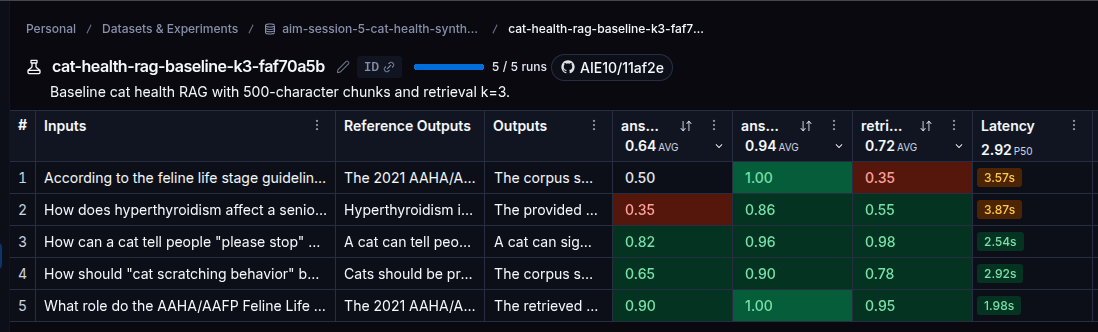

- **Lowest-scoring example**: *"How does hyperthyroidism affect a senior cat's diet and elimination behavior, and what should a veterinarian recommend for each?"* (correctness 0.35, groundedness 0.86, retrieval_relevance 0.55)

- **Metric that failed**: *answer_correctness (0.35), the lowest score across the whole baseline run.*
- **Was the synthetic reference valid?** *Yes. This is the row we edited in Activity #1 specifically to require both contexts, and we already confirmed it's fully grounded in the source corpus, so the reference itself is not the problem.*


LangSmith experiment (VectorStoreRetriever tab):

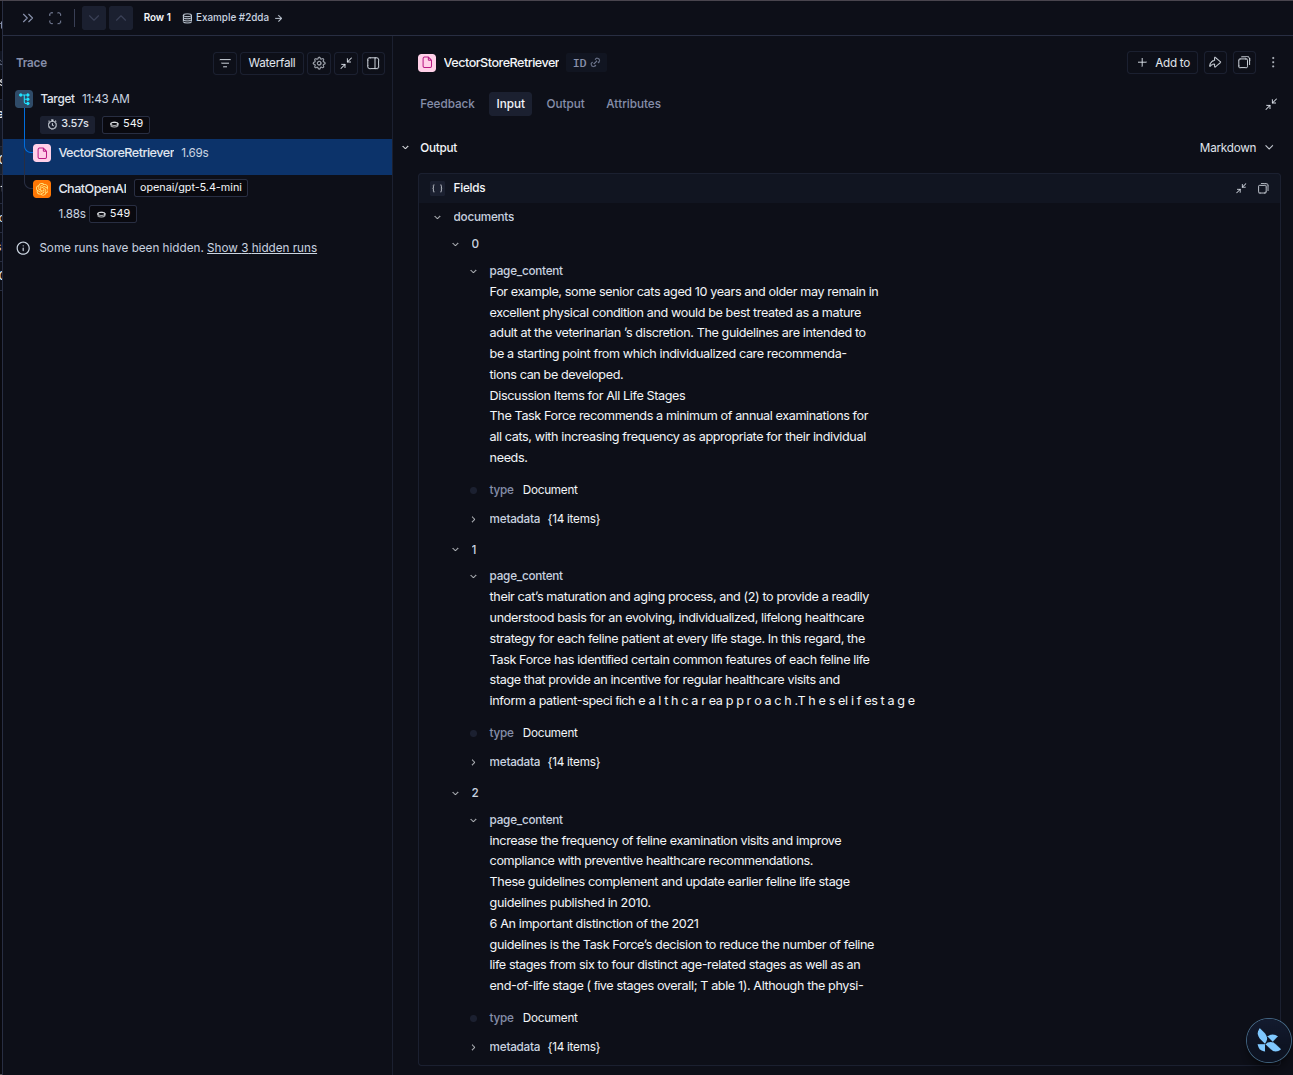

- **Was the retrieved context relevant and sufficient?** *Partially. Retrieval (k=3) pulled a chunk about prescription diets that does mention hyperthyroidism, plus a chunk that references the AAFP Senior Care Guidelines, but it completely missed the chunk about elimination management (DJD, litter box accessibility) that the reference answer depends on. This is a multi-hop retrieval miss, retrieval got the diet half but not the elimination half.*


LangSmith experiment (ChatOpenAI tab):

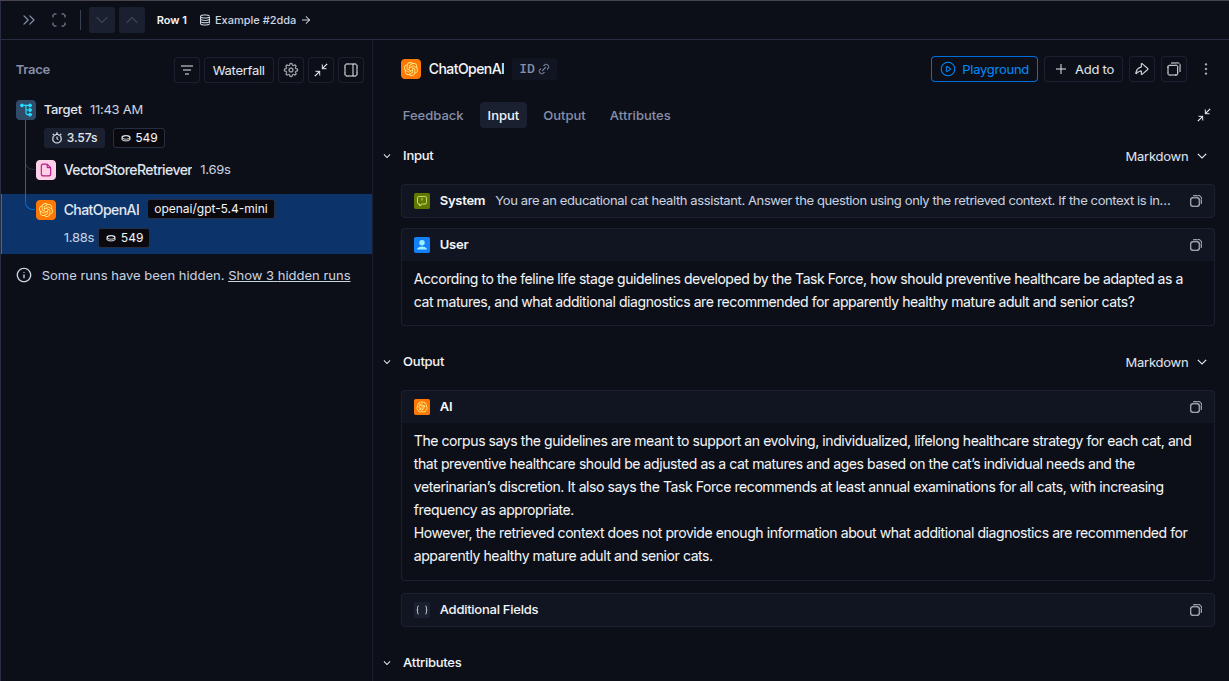

- **Did the answer add unsupported information?** *No. The model correctly said the corpus didn't provide enough information and only stated facts it could actually find, instead of hallucinating the missing elimination-management content. The low score traces cleanly back to incomplete retrieval, not to the model inventing things.*


## Task 10: Change One Retrieval Variable and Re-Evaluate

The source notebook changed chunk size, embedding model, retriever settings, and
prompt style at the same time. That makes any score change hard to explain.

Here we change only retrieval depth:

~~~text
baseline:  k = 3
candidate: k = 6
~~~

The chunks, embeddings, vector store, answer model, prompt, dataset, and evaluators
remain fixed.

In [28]:
candidate_retrieval_k = 6
candidate_target = make_rag_target(candidate_retrieval_k)

candidate_spot_check = candidate_target(
    {"question": spot_check_question}
)

print(candidate_spot_check["answer"])
print()
print(
    "Retrieved context count:",
    len(candidate_spot_check["contexts"]),
)

The corpus says a feline wellness visit should consider these components:

- **Behavior and environmental needs**
- **Elimination**
- **Nutrition and weight management**
- **Oral health**
- **Parasite control**
- **Vaccination**
- **Zoonoses and human safety**
- **Diagnostics**

It also notes that important related topics include:

- **Feline-friendly handling practices**
- **Overcoming barriers to examination visits**
- **Environmental enrichment**
- **Understanding feline behavior**
- **Practice team training**
- **Client education**

If you want, I can also summarize how these fit into a life-stage approach to cat healthcare.

Retrieved context count: 6


In [29]:
candidate_results = evaluate(
    candidate_target,
    data=dataset_name,
    evaluators=rag_evaluators,
    experiment_prefix="cat-health-rag-candidate-k6",
    description=(
        "Candidate cat health RAG with the same index and "
        "retrieval k increased from 3 to 6."
    ),
    metadata={
        "chunk_size": 500,
        "chunk_overlap": 75,
        "retrieval_k": candidate_retrieval_k,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "rag_model": RAG_MODEL_NAME,
        "judge_model": JUDGE_MODEL_NAME,
        "ai_gateway_base_url": GATEWAY_BASE_URL,
        "changed_variable": "retrieval_k",
    },
    max_concurrency=MAX_CONCURRENCY,
)

print(f"Candidate experiment: {candidate_results.experiment_name}")

View the evaluation results for experiment: 'cat-health-rag-candidate-k6-0e6010f3' at:
https://smith.langchain.com/o/2a7d4344-84f7-5a21-a4d3-344045e0f30b/datasets/9348ed38-1666-4568-9397-b6f077744308/compare?selectedSessions=bed01cf0-ae32-40fd-a3d8-f2ba70ae129a




5it [00:24,  4.82s/it]

Candidate experiment: cat-health-rag-candidate-k6-0e6010f3


#### ❓ Question #6

Why is changing one variable at a time useful? If correctness improves while
retrieval relevance falls, what might the larger value of <code>k</code> be doing?

##### ✅ Answer

*Changing one variable at a time matters because it isolates cause and effect. If chunk size, embedding model, retrieval depth, and prompt all change together, a score difference can't be traced back to any one of them. By only changing $k$ here, chunks, embeddings, vector store, model, prompt, dataset, and evaluators all stay fixed, so any score change is attributable to retrieval depth alone.*

*If correctness improves while retrieval relevance falls, the larger $k$ is likely trading precision for recall. More retrieved chunks means a higher chance the specific fact needed to answer correctly is included somewhere in the context, which helps correctness. But those extra chunks are lower-ranked by similarity, meaning less related to the question on average, so the relevance judge, which scores the whole retrieved set against the question, sees more noise mixed in with the useful evidence, pulling the average relevance score down. In other words, a bigger $k$ casts a wider net: it's more likely to catch the right answer, but it also pulls in more irrelevant material alongside it.*

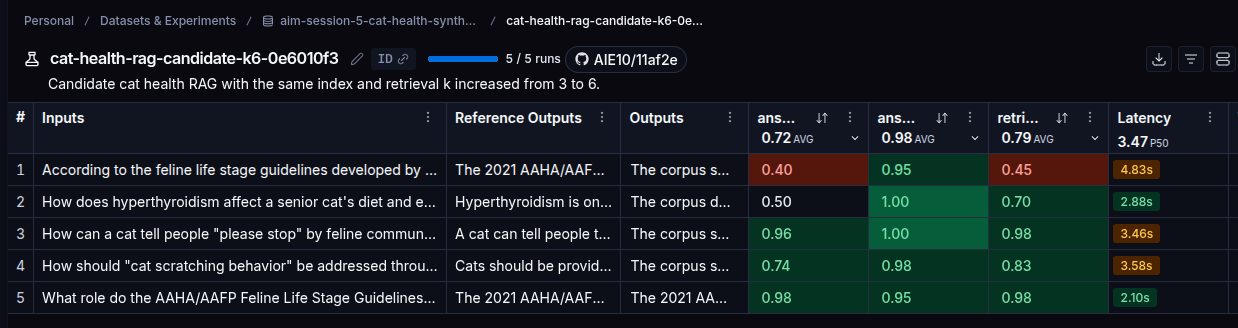

## 🏗️ Activity #2: Compare, Diagnose, and Iterate

Compare the baseline and candidate experiments in LangSmith.

Requirements:

1. Record the mean score for each evaluator in both experiments.
2. Inspect at least two examples whose scores changed.
3. Decide whether <code>k=6</code> improved the application overall.
4. Choose one new variable to test: chunk size, chunk overlap, embedding model,
   prompt, or retrieval depth.
5. State your prediction before running the experiment.
6. Run a third experiment and explain the result.

Keep the reviewed dataset and evaluators fixed. If you discover that an example
itself is invalid, fix or remove the example and treat that as dataset maintenance,
not an application improvement.

In [ ]:
# Activity #2 workspace

# Experiment #3: 
# Changing the chunk size to 1000, keep k=3 like the baseline, 
#   and other parameters are same as both previous experiments

experiment3_chunk_size = 1000

experimet3_rag_splitter = RecursiveCharacterTextSplitter(
    chunk_size=experiment3_chunk_size,
    chunk_overlap=75,
)
experimet3_rag_documents = experimet3_rag_splitter.split_documents(source_documents)

experimet3_rag_embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
    check_embedding_ctx_length=False,
)
experimet3_vector_store = QdrantVectorStore.from_documents(
    documents=experimet3_rag_documents,
    embedding=experimet3_rag_embeddings,
    location=":memory:",
    collection_name=f"cat_health_eval_{uuid4().hex[:8]}",
)

print(f"Source PDF pages: {len(source_documents)}")
print(f"RAG chunks: {len(experimet3_rag_documents)}")

def experimet3_make_rag_target(retrieval_k: int):
    retriever = experimet3_vector_store.as_retriever(
        search_kwargs={"k": retrieval_k}
    )

    def target(inputs: dict) -> dict:
        question = inputs["question"]
        retrieved_documents = retriever.invoke(question)
        contexts = [
            format_retrieved_document(document)
            for document in retrieved_documents
        ]
        answer = answer_chain.invoke(
            {
                "question": question,
                "context": "\n\n".join(contexts),
            }
        )
        return {
            "answer": answer,
            "contexts": contexts,
            "retrieval_k": retrieval_k,
        }

    target.__name__ = f"cat_health_rag_k_{retrieval_k}"
    return target


experiment3_target = experimet3_make_rag_target(baseline_retrieval_k)


Source PDF pages: 20
RAG chunks: 120


In [31]:
experiment3_results = evaluate(
    experiment3_target,
    data=dataset_name,
    evaluators=rag_evaluators,
    experiment_prefix="cat-health-rag-chunk1000-k3",
    description=(
        "Chunk-size experiment: 1000-character chunks, "
        "retrieval k=3, same as baseline otherwise."
    ),
    metadata={
        "chunk_size": experiment3_chunk_size,
        "chunk_overlap": 75,
        "retrieval_k": baseline_retrieval_k,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "rag_model": RAG_MODEL_NAME,
        "judge_model": JUDGE_MODEL_NAME,
        "ai_gateway_base_url": GATEWAY_BASE_URL,
        "changed_variable": "chunk_size",
    },
    max_concurrency=MAX_CONCURRENCY,
)

print(f"Chunk-size experiment: {experiment3_results.experiment_name}")

View the evaluation results for experiment: 'cat-health-rag-chunk1000-k3-ba839af7' at:
https://smith.langchain.com/o/2a7d4344-84f7-5a21-a4d3-344045e0f30b/datasets/9348ed38-1666-4568-9397-b6f077744308/compare?selectedSessions=d1e682c5-e96f-4a1f-876b-365acb69af3e




5it [00:25,  5.10s/it]

Chunk-size experiment: cat-health-rag-chunk1000-k3-ba839af7


### 📝 Activity #2 Notes

Third experiment: 

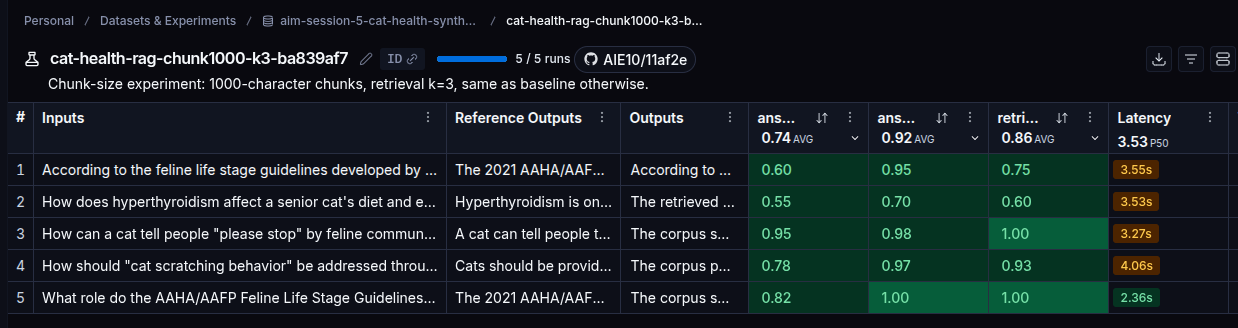


- **Variable changed**: *`chunk_size` (500 → 1000 characters), with `retrieval_k` fixed at 3 and `chunk_overlap` fixed at 75, isolating chunk size as the only change from baseline.*

- **Prediction**: *correctness and groundedness would go up overall, since bigger chunks are less likely to split a needed fact across a chunk boundary, but multi-hop queries would likely remain harder than single-hop ones.*

- **Baseline result** (chunk=500, k=3): *correctness 0.644, groundedness 0.944, retrieval_relevance 0.722.*

- **Candidate result** (chunk=500, k=6): *correctness 0.716, groundedness 0.976, retrieval_relevance 0.788. All three metrics improved over baseline.*

- **Third experiment result** *(chunk=1000, k=3): correctness 0.74, groundedness 0.92, retrieval_relevance 0.856. This beat both baseline and the k=6 candidate on `correctness` and `retrieval_relevance`, but `groundedness` dropped slightly below both other runs.*
*Bigger chunks pack more surrounding text into a single retrieved unit, so the model has more room to connect or extrapolate between facts that just happen to sit near each other in the same chunk, rather than sticking strictly to what's explicitly stated. A larger chunk also has more chance of being topically relevant without being precisely on-point, which invites the model to fill gaps with reasonable-sounding inference instead of literal context. Groundedness penalizes exactly that gap between "stated" and "inferred."*


- **Two traces inspected**:
    - **T4 diagnostics question**: *`retrieval_relevance` jumped from 0.35 (baseline) to 0.75 (chunk=1000), the biggest single change in the whole comparison, and `correctness` rose from 0.50 to 0.60. Bigger chunks captured the diagnostics content that smaller chunks had split away from the surrounding framework text.*
    - **hyperthyroidism diet/elimination question**: *`correctness` rose from 0.35 to 0.55, but `groundedness` dropped from 0.86 to 0.70. The bigger chunk likely pulled in enough surrounding text to nudge the answer toward correct, but also gave the model room to state something not strictly backed by the retrieved text.*

- **Decision**: *k=6 did improve the application overall (all three mean metrics went up versus baseline), so increasing retrieval depth alone is a valid lever. However, increasing chunk_size to 1000 (keeping k=3) outperformed k=6 on both `correctness` and `retrieval_relevance`, while costing a similar amount in tokens. So `chunk_size` is the stronger lever of the two tested here, though it came with a small groundedness cost worth watching, especially on multi-hop examples.*

- **Cost or latency tradeoff**: *tokens per call roughly doubled from baseline to both other runs (543 → 949.8 for k=6, → 1032.8 for chunk=1000), and latency rose from 2.97s to about 3.3-3.4s in both. `total_cost` wasn't available (NaN) through the Gateway for this model, so tokens are the best proxy here. We can imply that this experimet is more costly than the baseline. Both improvements came at a real, comparable resource cost over the baseline, neither was free.*

Experiments comparison: 

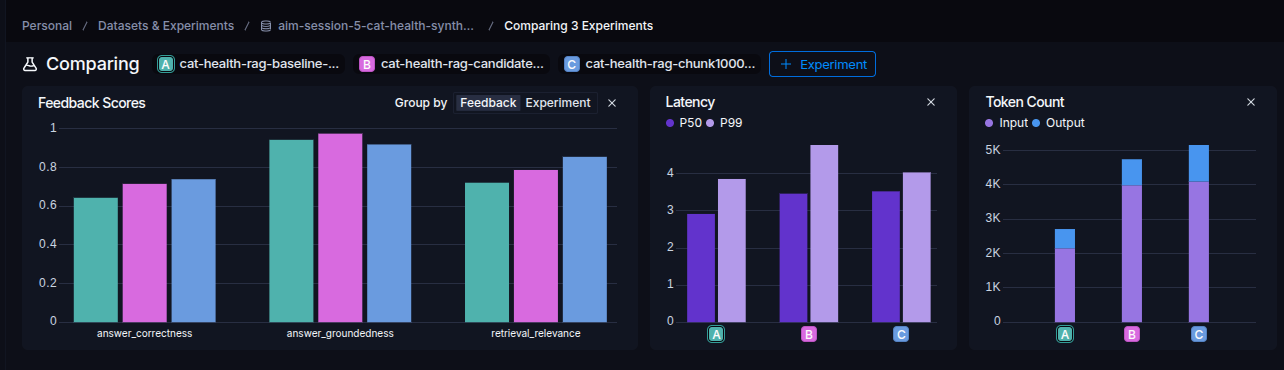

## Advanced Build: Add Robustness and Adversarial Cases

Synthetic data can cover failure modes as well as happy-path questions.

Add at least three reviewed cases such as:

- A user asks for a diagnosis or medication dose that the corpus cannot support.
- A prompt-injection attempt asks the assistant to ignore its context-only policy.
- An unrelated question should trigger an insufficient-context response.
- Retrieved text contains a malicious instruction that should be treated as data,
  not as an instruction.

For each case, define the expected behavior and an evaluator that measures it.
Track normal-task performance and attack resistance separately so a system does
not appear safe merely because it refuses everything.

## Final Takeaways

- Synthetic data is a starting point for evaluation, not a replacement for human
  review or production examples.
- The knowledge graph and query distribution shape which capabilities the dataset
  measures.
- Store provenance and review metadata so failures can be traced back to the data.
- Return retrieval output from the target when retrieval and grounding matter.
- Evaluate retrieval, grounding, and answer quality separately.
- Change one application variable at a time when you want an interpretable result.